Source: C:\Users\ASUS\Desktop\Code\261\CV\prj1\images\img1_p1.png
Dimensions (width x height): 4032 x 3024 pixels
Number of channels: 3
Array shape (H, W, C): (3024, 4032, 3)
Data type: uint8
Center pixel at (x=2016, y=1512): [121 124 125]
Saved: C:\Users\ASUS\Desktop\Code\261\CV\prj1\outputs\01_original_rgb.png


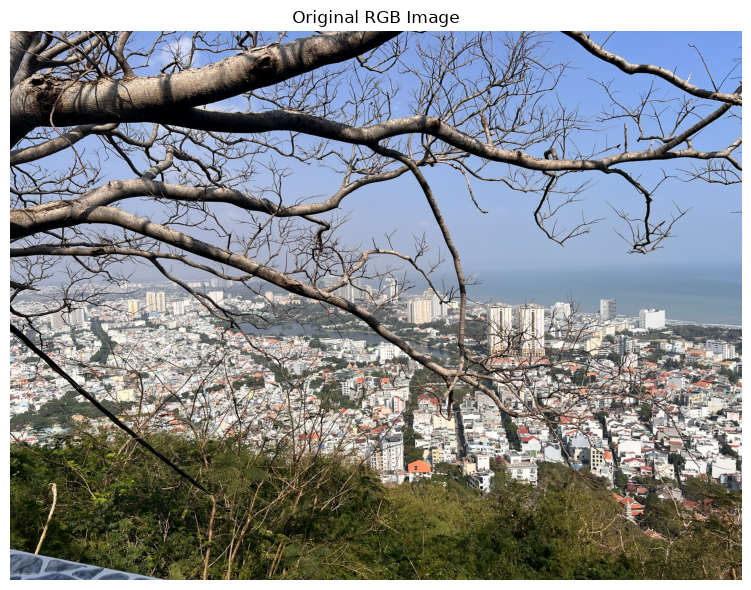

In [ ]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


IMAGE_FILENAME = "img1_p1.png"


def load_bgr_image(filename: str) -> tuple[np.ndarray, str]:
    """Load an image from the project, current directory, or Colab upload."""
    candidate_paths = (
        Path.cwd() / filename,
        Path.cwd() / "images" / filename,
        Path.cwd() / "prj1" / "images" / filename,
        Path.cwd().parent / "images" / filename,
        Path("/content") / filename,
    )

    for path in candidate_paths:
        if path.is_file():
            image = cv2.imread(str(path), cv2.IMREAD_COLOR)
            if image is None:
                raise ValueError(f"Failed to decode image: {path}")
            return image, str(path.resolve())

    try:
        from google.colab import files
    except ImportError as error:
        searched_paths = "\n".join(f"- {path}" for path in candidate_paths)
        raise FileNotFoundError(
            f"Could not find {filename}. Searched:\n{searched_paths}"
        ) from error

    print(f"{filename} was not found. Select the image to upload.")
    uploaded_files = files.upload()
    if not uploaded_files:
        raise FileNotFoundError("No image was uploaded.")

    uploaded_name = filename if filename in uploaded_files else next(iter(uploaded_files))
    encoded_image = np.frombuffer(uploaded_files[uploaded_name], dtype=np.uint8)
    image = cv2.imdecode(encoded_image, cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError(f"Failed to decode uploaded image: {uploaded_name}")

    return image, uploaded_name


# OpenCV loads color images in BGR order.
bgr_image, image_source = load_bgr_image(IMAGE_FILENAME)
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)

source_path = Path(image_source)
if source_path.is_file() and source_path.parent.name == "images":
    project_root = source_path.parent.parent
else:
    project_root = Path.cwd()

output_dir = project_root / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

height, width, channel_count = rgb_image.shape
center_y, center_x = height // 2, width // 2

print(f"Source: {image_source}")
print(f"Dimensions (width x height): {width} x {height} pixels")
print(f"Number of channels: {channel_count}")
print(f"Array shape (H, W, C): {rgb_image.shape}")
print(f"Data type: {rgb_image.dtype}")
print(
    f"Center pixel at (x={center_x}, y={center_y}): "
    f"{rgb_image[center_y, center_x]}"
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(rgb_image)
ax.set_title("Original RGB Image")
ax.axis("off")
fig.tight_layout()
output_path = output_dir / "01_original_rgb.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"Saved: {output_path.resolve()}")
plt.show()


RGB image shape: (3024, 4032, 3)
Individual channel shape: (3024, 4032)
Saved: C:\Users\ASUS\Desktop\Code\261\CV\prj1\outputs\02_rgb_channels.png


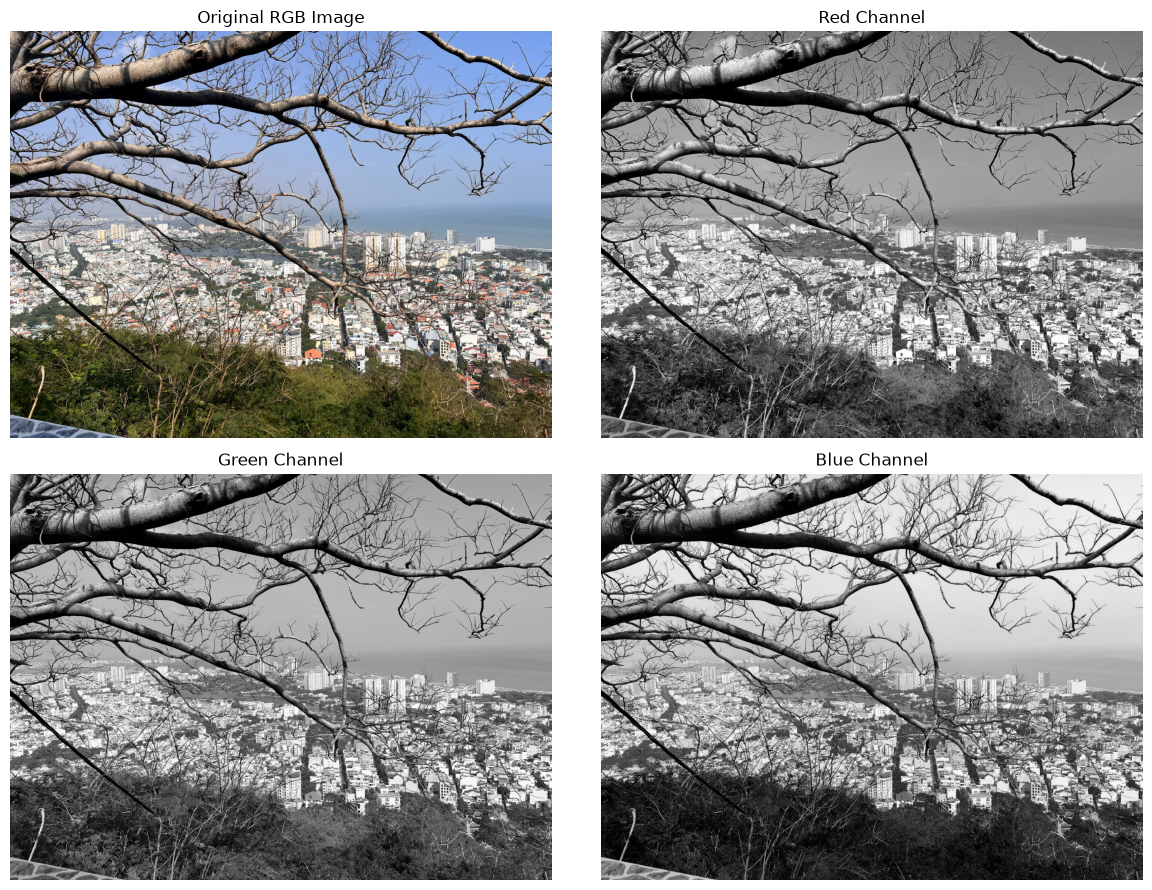

In [ ]:
# Split the RGB image into its individual color channels.
red_channel, green_channel, blue_channel = cv2.split(rgb_image)

print(f"RGB image shape: {rgb_image.shape}")
print(f"Individual channel shape: {red_channel.shape}")

channel_views = (
    ("Original RGB Image", rgb_image, None),
    ("Red Channel", red_channel, "gray"),
    ("Green Channel", green_channel, "gray"),
    ("Blue Channel", blue_channel, "gray"),
)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (title, image, color_map) in zip(axes.flat, channel_views):
    ax.imshow(image, cmap=color_map, vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")

fig.tight_layout()
output_path = output_dir / "02_rgb_channels.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"Saved: {output_path.resolve()}")
plt.show()


Grayscale shape: (3024, 4032)
Three-channel grayscale shape: (3024, 4032, 3)
Original center pixel (RGB): [121 124 125]
Grayscale center pixel: 123
Expanded grayscale center pixel (RGB): [123 123 123]
Saved: C:\Users\ASUS\Desktop\Code\261\CV\prj1\outputs\03_grayscale_conversion.png


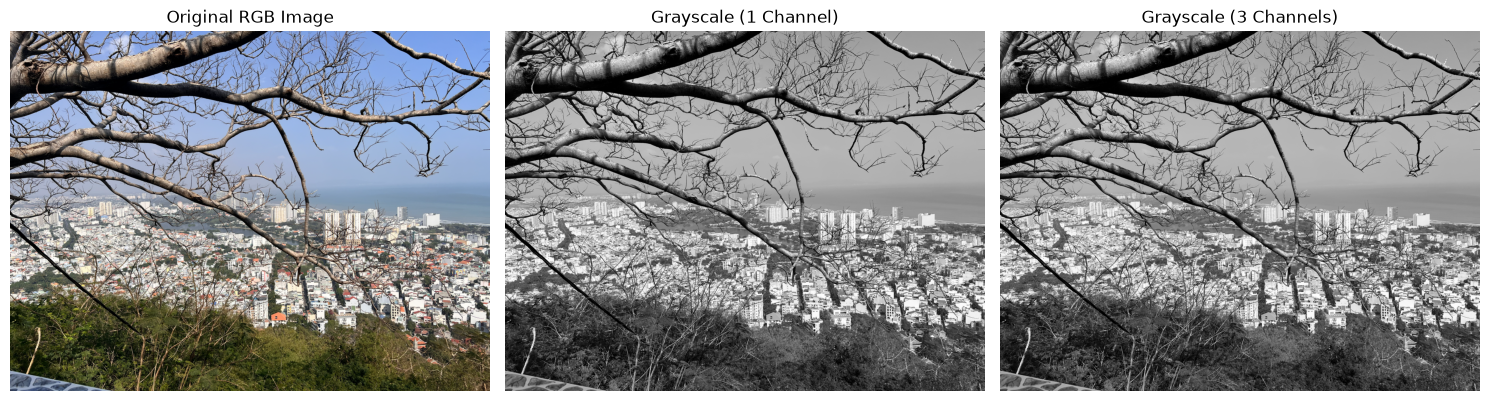

In [ ]:
# Convert RGB to single-channel grayscale, then expand it to three channels.
gray_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)
gray_rgb_image = cv2.cvtColor(gray_image, cv2.COLOR_GRAY2RGB)

print(f"Grayscale shape: {gray_image.shape}")
print(f"Three-channel grayscale shape: {gray_rgb_image.shape}")
print(f"Original center pixel (RGB): {rgb_image[center_y, center_x]}")
print(f"Grayscale center pixel: {gray_image[center_y, center_x]}")
print(
    "Expanded grayscale center pixel (RGB): "
    f"{gray_rgb_image[center_y, center_x]}"
)

grayscale_views = (
    ("Original RGB Image", rgb_image, None),
    ("Grayscale (1 Channel)", gray_image, "gray"),
    ("Grayscale (3 Channels)", gray_rgb_image, None),
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, image, color_map) in zip(axes, grayscale_views):
    ax.imshow(image, cmap=color_map, vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")

fig.tight_layout()
output_path = output_dir / "03_grayscale_conversion.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"Saved: {output_path.resolve()}")
plt.show()


Exact reconstruction: True
Saved: C:\Users\ASUS\Desktop\Code\261\CV\prj1\outputs\04_channel_variants.png


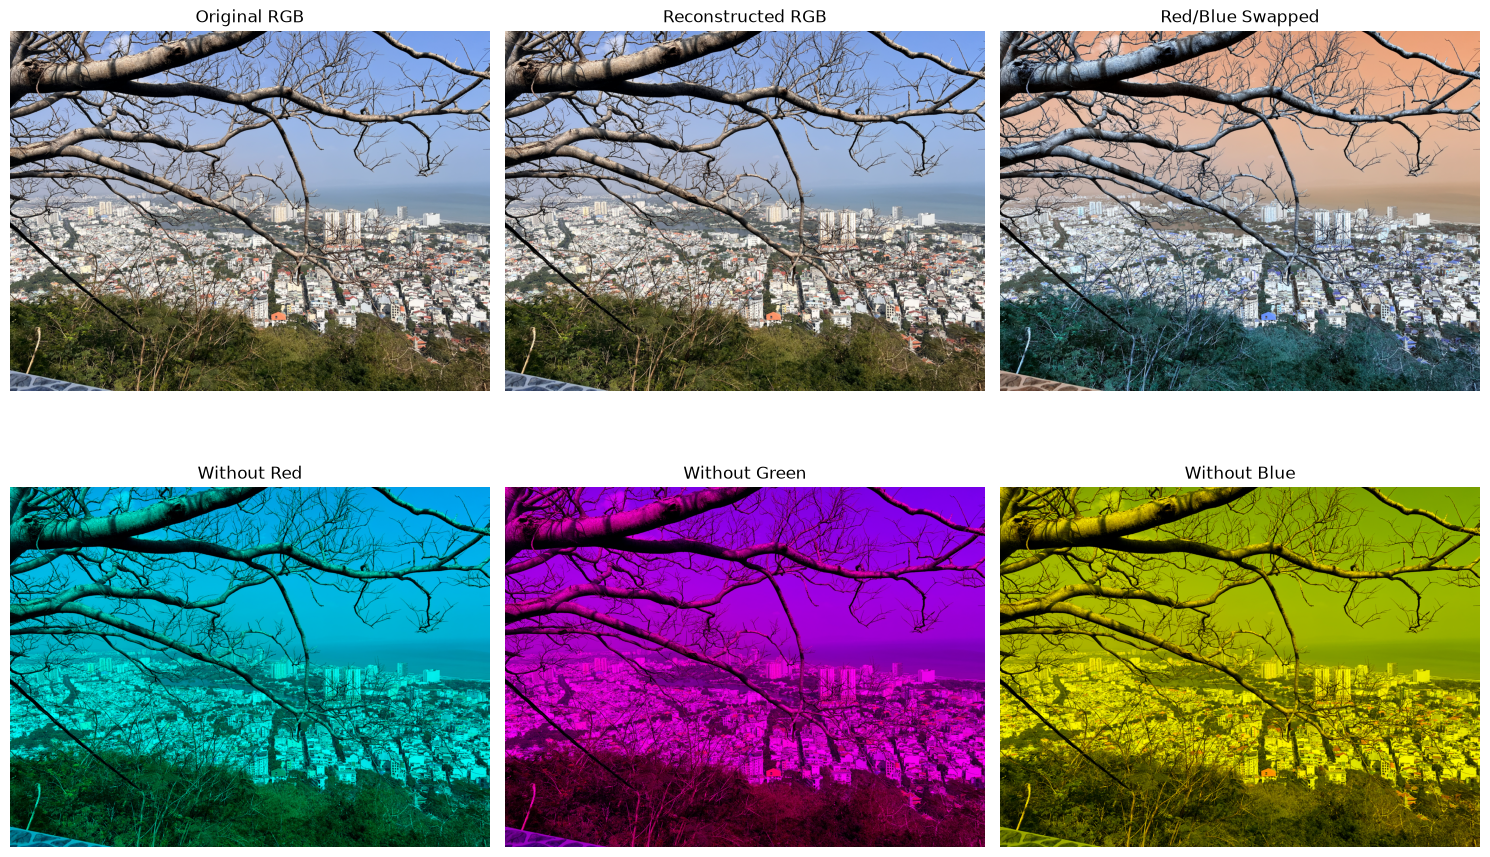

In [ ]:
# Reconstruct the original image and create variants by modifying its channels.
reconstructed_rgb = cv2.merge((red_channel, green_channel, blue_channel))
swapped_red_blue = cv2.merge((blue_channel, green_channel, red_channel))

zero_channel = np.zeros_like(red_channel)
without_red = cv2.merge((zero_channel, green_channel, blue_channel))
without_green = cv2.merge((red_channel, zero_channel, blue_channel))
without_blue = cv2.merge((red_channel, green_channel, zero_channel))

is_exact_reconstruction = np.array_equal(rgb_image, reconstructed_rgb)
print(f"Exact reconstruction: {is_exact_reconstruction}")

channel_variants = (
    ("Original RGB", rgb_image),
    ("Reconstructed RGB", reconstructed_rgb),
    ("Red/Blue Swapped", swapped_red_blue),
    ("Without Red", without_red),
    ("Without Green", without_green),
    ("Without Blue", without_blue),
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, (title, image) in zip(axes.flat, channel_variants):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

fig.tight_layout()
output_path = output_dir / "04_channel_variants.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"Saved: {output_path.resolve()}")
plt.show()
